In [1]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))

import datetime
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.ticker import MultipleLocator
from scipy.spatial import cKDTree
from zhiyi.analysis.SE_analysis import get_site_index


In [2]:
SCRIP_file = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"

bb_base_files = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc"
nobb_base_files = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_NOBB_month6/atm/hist/MUSICA_production3.2_NOBB_month6.cam.h2.2018-MM-DD-03600.nc"

CO_START_DATE = datetime.date(2018, 6, 23)
CO_END_DATE = datetime.date(2018, 7, 2)
O3_BB_START_DATE = datetime.date(2018, 6, 22)
O3_BB_END_DATE = datetime.date(2018, 7, 15)
O3_NOBB_START_DATE = datetime.date(2018, 6, 22)
O3_NOBB_END_DATE = datetime.date(2018, 7, 2)
PLOT_START_DATE = "2018-06-24"
PLOT_END_DATE = "2018-06-30"

city_lonlat = {
    "Manchester": [360 - 2.237881, 53.481520],
    "Liverpool": [360 - 2.960989, 53.424225],
    "Sheffield": [360 - 1.455815, 53.404950],
    "Birmingham": [360 - 1.874978, 52.476145],
}

co_cities = ["Liverpool", "Sheffield", "Manchester", "Birmingham"]
o3_cities = ["Manchester", "Sheffield", "Liverpool", "Birmingham"]
co_colors = ["dimgrey", "navajowhite", "cornflowerblue", "darksalmon"]


In [33]:
def collect_files(template, start, end):
    files = []
    current = start
    while current <= end:
        file_path = (
            template
            .replace("YYYY", current.strftime("%Y"))
            .replace("MM", current.strftime("%m"))
            .replace("DD", current.strftime("%d"))
        )
        if os.path.exists(file_path):
            files.append(file_path)
        else:
            print(f"Warning: File not found - {file_path}, skipping this file.")
        current += datetime.timedelta(days=1)

    if not files:
        raise FileNotFoundError(f"No files found for template '{template}' between {start} and {end}.")
    return files


def to_london_naive(time_values):
    return pd.to_datetime(time_values).tz_localize("UTC").tz_convert("Europe/London").tz_localize(None)


def build_figure_s19_plot_data(ds_co, ds_bb, ds_nobb):
    index_lonlat = {}
    for city, (lon360, lat) in city_lonlat.items():
        index_lonlat[city] = get_site_index(lon360, lat, scrip_file=SCRIP_file)

    co_time = to_london_naive(ds_co.time.values)
    co_data = np.asarray([
        ds_co["CO"].values[:, -1, index_lonlat[city]] * 1e9
        for city in co_cities
    ])

    lon360 = ds_bb["lon"].isel(time=0).values
    lat = ds_bb["lat"].isel(time=0).values
    lon180 = (lon360 + 180) % 360 - 180
    lon360_nobb = ds_nobb["lon"].isel(time=0).values
    lat_nobb = ds_nobb["lat"].isel(time=0).values
    lon180_nobb = (lon360_nobb + 180) % 360 - 180

    tree = cKDTree(np.vstack([lat, lon180]).T)
    tree_nobb = cKDTree(np.vstack([lat_nobb, lon180_nobb]).T)
    time_bb = to_london_naive(ds_bb.time.values)
    time_nobb = to_london_naive(ds_nobb.time.values)

    k_cover = 9
    city_pct = {}
    all_days = None
    for city in o3_cities:
        lon_c360, lat_c = city_lonlat[city]
        lon_c180 = (lon_c360 + 180) % 360 - 180
        _, idx_bb = tree.query([lat_c, lon_c180], k=k_cover)
        _, idx_nobb = tree_nobb.query([lat_c, lon_c180], k=k_cover)

        o3_bb = ds_bb["O3"].values[:, -1, idx_bb] * 1e9
        o3_nobb = ds_nobb["O3"].values[:, -1, idx_nobb] * 1e9

        df_bb = pd.DataFrame(o3_bb, index=time_bb).asfreq("h")
        df_nobb = pd.DataFrame(o3_nobb, index=time_nobb).asfreq("h")
        mda8_bb = df_bb.rolling(window=8, min_periods=8).mean().resample("D").max()
        mda8_nobb = df_nobb.rolling(window=8, min_periods=8).mean().resample("D").max()

        days = mda8_bb.index.intersection(mda8_nobb.index)
        mda8_bb = mda8_bb.loc[days]
        mda8_nobb = mda8_nobb.loc[days]
        mean_bb = np.nanmean(mda8_bb.values, axis=1)
        mean_nobb = np.nanmean(mda8_nobb.values, axis=1)
        city_pct[city] = pd.Series(100.0 * (mean_bb - mean_nobb) / mean_nobb, index=days).loc[PLOT_START_DATE:PLOT_END_DATE]
        all_days = city_pct[city].index if all_days is None else all_days.intersection(city_pct[city].index)

    o3_dates = pd.DatetimeIndex(all_days)
    o3_increase_pct = pd.DataFrame(index=o3_cities, columns=o3_dates, dtype=float)
    for city in o3_cities:
        o3_increase_pct.loc[city, :] = city_pct[city].loc[o3_dates].values

    o3_mean_increase_pct = o3_increase_pct.mean(axis=1)
    return co_time, co_data, o3_increase_pct, o3_mean_increase_pct


def plot_figure_s19(co_time, co_data, o3_increase_pct, o3_mean_increase_pct):
    co_color_map = {
        "Liverpool": "dimgrey",
        "Sheffield": "navajowhite",
        "Manchester": "cornflowerblue",
        "Birmingham": "darksalmon",
    }
    co_series = {
        city: np.asarray(co_data[i]).squeeze()
        for i, city in enumerate(co_cities)
    }

    fig, (ax_a, ax_b) = plt.subplots(
        2,
        1,
        figsize=(6.2, 8.6),
        gridspec_kw={"height_ratios": [1.0, 1.08]},
    )
    fig.subplots_adjust(left=0.14, right=0.88, top=0.97, bottom=0.08, hspace=0.14)

    plot_order = ["Liverpool", "Sheffield", "Manchester", "Birmingham"]
    for city in plot_order:
        ax_a.fill_between(
            co_time,
            co_series[city],
            0,
            color=co_color_map[city],
            alpha=1,
            linewidth=0,
            label=city,
        )

    legend_order = ["Liverpool", "Sheffield", "Manchester", "Birmingham"]
    legend_handles = [
        mpatches.Patch(color=co_color_map[city], alpha=0.9, label=city)
        for city in legend_order
    ]
    ax_a.legend(
        handles=legend_handles,
        fontsize=10,
        loc="upper right",
        frameon=True,
        fancybox=False,
        borderpad=0.25,
        handlelength=1.6,
        labelspacing=0.2,
    )

    ax_a.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax_a.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax_a.set_xlim(pd.Timestamp("2018-06-24"), pd.Timestamp("2018-07-01"))
    co_ymax = np.nanmax(np.vstack([co_series[city] for city in plot_order]))
    ax_a.set_ylim(0, max(650, np.ceil(co_ymax / 100) * 100 + 50))
    ax_a.yaxis.set_major_locator(MultipleLocator(100))
    ax_a.yaxis.set_minor_locator(MultipleLocator(50))
    ax_a.tick_params(axis="x", which="major", labelsize=14, pad=4, length=3.5, width=0.6)
    ax_a.tick_params(axis="y", which="major", labelsize=14, pad=4, length=3.5, width=0.6)
    ax_a.tick_params(axis="y", which="minor", length=2.0, width=0.5)
    # ax_a.set_xlabel("Date", fontsize=8, labelpad=2)
    ax_a.set_ylabel("CO (ppbv)", fontsize=11)
    ax_a.grid(True, which="major", linestyle="--", linewidth=0.45, alpha=0.45)
    ax_a.set_axisbelow(True)
    ax_a.text(
        0.015,
        0.98,
        "(a)",
        transform=ax_a.transAxes,
        fontsize=12,
        va="top",
        ha="left",
        weight="bold",
    )

    im = ax_b.imshow(
        o3_increase_pct.values.astype(float),
        aspect="auto",
        cmap="RdBu_r",
        vmin=-20,
        vmax=30,
        interpolation="nearest",
    )
    ax_b.set_yticks(np.arange(len(o3_increase_pct.index)))
    ax_b.set_yticklabels(o3_increase_pct.index, fontsize=12, rotation=90, va="center")
    ax_b.tick_params(axis="y", pad=9, length=3)
    ax_b.set_xticks(np.arange(len(o3_increase_pct.columns)))
    ax_b.set_xticklabels(
        [pd.Timestamp(d).strftime("%m-%d") for d in o3_increase_pct.columns],
        ha="center",
        fontsize=13,
    )
    ax_b.tick_params(axis="x", pad=6, length=3)
    # ax_b.set_xlabel("Date", fontsize=8, labelpad=2)

    for i, city in enumerate(o3_increase_pct.index):
        for j, d in enumerate(o3_increase_pct.columns):
            val = o3_increase_pct.loc[city, d]
            if pd.notna(val):
                ax_b.text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=12, color="black")

    ax_b.text(
        0.015,
        0.98,
        "(b)",
        transform=ax_b.transAxes,
        fontsize=12,
        va="top",
        ha="left",
        weight="bold",
        bbox=dict(facecolor="white", edgecolor="none", boxstyle="square,pad=0.20", alpha=1),
    )

    for ax in (ax_a, ax_b):
        for spine in ax.spines.values():
            spine.set_linewidth(0.6)
            spine.set_color("0.35")

    pos = ax_b.get_position()
    cbar_ax = fig.add_axes([pos.x1 + 0.022, pos.y0 + 0.08 * pos.height, 0.018, 0.84 * pos.height])
    cbar = fig.colorbar(
        im,
        cax=cbar_ax,
        orientation="vertical",
        extend="both",
        ticks=[-20, -10, 0, 10, 20, 30],
    )
    cbar.ax.tick_params(labelsize=11, length=2.0, width=0.5, pad=1.5)
    cbar.set_label("MDA8 O$_3$ increase (%)", fontsize=11, labelpad=4)
    cbar.outline.set_linewidth(0.6)
    return fig, (ax_a, ax_b)


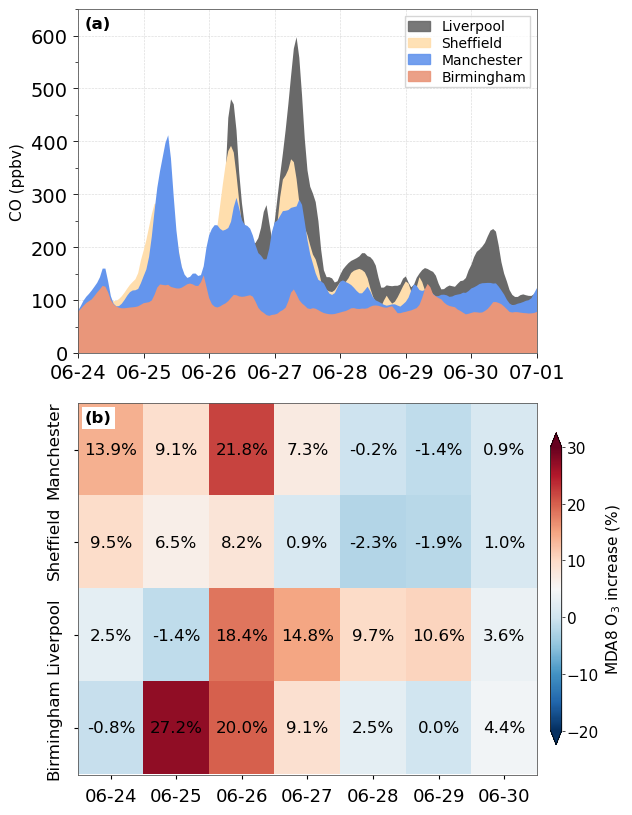

In [34]:
co_files = collect_files(bb_base_files, CO_START_DATE, CO_END_DATE)
bb_files = collect_files(bb_base_files, O3_BB_START_DATE, O3_BB_END_DATE)
nobb_files = collect_files(nobb_base_files, O3_NOBB_START_DATE, O3_NOBB_END_DATE)

ds_co = xr.open_mfdataset(co_files, combine="by_coords")
ds_bb = xr.open_mfdataset(bb_files, combine="by_coords")
ds_nobb = xr.open_mfdataset(nobb_files, combine="by_coords")

co_time, co_data, o3_increase_pct, o3_mean_increase_pct = build_figure_s19_plot_data(ds_co, ds_bb, ds_nobb)
fig, axes = plot_figure_s19(co_time, co_data, o3_increase_pct, o3_mean_increase_pct)


In [36]:
figure_data_dir = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data"
figure_s19_nc = os.path.join(figure_data_dir, "FigureS19.nc")
os.makedirs(figure_data_dir, exist_ok=True)

figure_s19_data = xr.Dataset(
    data_vars={
        "co_timeseries": (("city_co", "time_co"), np.asarray(co_data, dtype=float)),
        "mda8_o3_increase_pct": (("city_o3", "date"), o3_increase_pct.values.astype(float)),
        "mean_mda8_o3_increase_pct": (("city_o3",), o3_mean_increase_pct.reindex(o3_cities).values.astype(float)),
    },
    coords={
        "city_co": co_cities,
        "time_co": [pd.Timestamp(t).strftime("%Y-%m-%d %H:%M:%S") for t in co_time],
        "city_o3": o3_cities,
        "date": [pd.Timestamp(d).strftime("%Y-%m-%d") for d in o3_increase_pct.columns],
    },
    attrs={
        "description": "Figure S19 plotting data generated from original BB CO data and BB/NOBB MDA8 O3 data",
        "co_unit": "ppbv",
        "o3_increase_unit": "percent",
        "start_date": PLOT_START_DATE,
        "end_date": PLOT_END_DATE,
    },
)
figure_s19_data.to_netcdf(figure_s19_nc)
figure_s19_nc


'/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS19.nc'

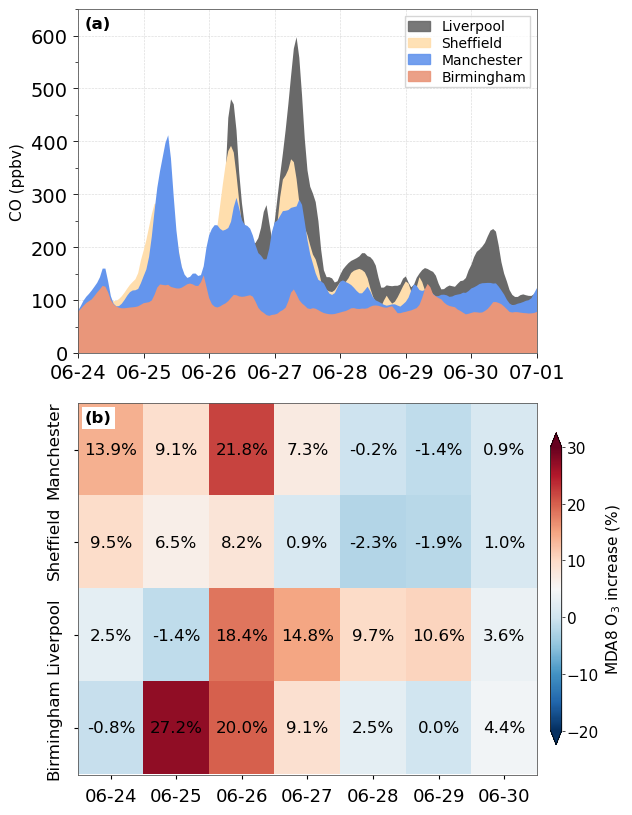

In [38]:
figure_s19_nc = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS19.nc"
figure_s19_saved = xr.open_dataset(figure_s19_nc)

co_time_saved = pd.to_datetime(figure_s19_saved["time_co"].values)
co_data_saved = figure_s19_saved["co_timeseries"].values
saved_co_cities = figure_s19_saved["city_co"].values.astype(str)

saved_o3_cities = figure_s19_saved["city_o3"].values.astype(str)
saved_o3_dates = pd.to_datetime(figure_s19_saved["date"].values)
o3_increase_pct_saved = pd.DataFrame(
    figure_s19_saved["mda8_o3_increase_pct"].values,
    index=saved_o3_cities,
    columns=saved_o3_dates,
)

co_color_map = {
    "Liverpool": "dimgrey",
    "Sheffield": "navajowhite",
    "Manchester": "cornflowerblue",
    "Birmingham": "darksalmon",
}
co_series = {
    city: np.asarray(co_data_saved[i]).squeeze()
    for i, city in enumerate(saved_co_cities)
}

fig, (ax_a, ax_b) = plt.subplots(
    2,
    1,
    figsize=(6.2, 8.6),
    gridspec_kw={"height_ratios": [1.0, 1.08]},
)
fig.subplots_adjust(left=0.14, right=0.88, top=0.97, bottom=0.08, hspace=0.14)

plot_order = ["Liverpool", "Sheffield", "Manchester", "Birmingham"]
for city in plot_order:
    ax_a.fill_between(
        co_time_saved,
        co_series[city],
        0,
        color=co_color_map[city],
        alpha=1,
        linewidth=0,
        label=city,
    )

legend_order = ["Liverpool", "Sheffield", "Manchester", "Birmingham"]
legend_handles = [
    mpatches.Patch(color=co_color_map[city], alpha=0.9, label=city)
    for city in legend_order
]
ax_a.legend(
    handles=legend_handles,
    fontsize=10,
    loc="upper right",
    frameon=True,
    fancybox=False,
    borderpad=0.25,
    handlelength=1.6,
    labelspacing=0.2,
)

ax_a.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax_a.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax_a.set_xlim(pd.Timestamp("2018-06-24"), pd.Timestamp("2018-07-01"))
co_ymax = np.nanmax(np.vstack([co_series[city] for city in plot_order]))
ax_a.set_ylim(0, max(650, np.ceil(co_ymax / 100) * 100 + 50))
ax_a.yaxis.set_major_locator(MultipleLocator(100))
ax_a.yaxis.set_minor_locator(MultipleLocator(50))
ax_a.tick_params(axis="x", which="major", labelsize=14, pad=4, length=3.5, width=0.6)
ax_a.tick_params(axis="y", which="major", labelsize=14, pad=4, length=3.5, width=0.6)
ax_a.tick_params(axis="y", which="minor", length=2.0, width=0.5)
# ax_a.set_xlabel("Date", fontsize=8, labelpad=2)
ax_a.set_ylabel("CO (ppbv)", fontsize=11)
ax_a.grid(True, which="major", linestyle="--", linewidth=0.45, alpha=0.45)
ax_a.set_axisbelow(True)
ax_a.text(
    0.015,
    0.98,
    "(a)",
    transform=ax_a.transAxes,
    fontsize=12,
    va="top",
    ha="left",
    weight="bold",
)

im = ax_b.imshow(
    o3_increase_pct_saved.values.astype(float),
    aspect="auto",
    cmap="RdBu_r",
    vmin=-20,
    vmax=30,
    interpolation="nearest",
)
ax_b.set_yticks(np.arange(len(o3_increase_pct_saved.index)))
ax_b.set_yticklabels(o3_increase_pct_saved.index, fontsize=12, rotation=90, va="center")
ax_b.tick_params(axis="y", pad=9, length=3)
ax_b.set_xticks(np.arange(len(o3_increase_pct_saved.columns)))
ax_b.set_xticklabels(
    [pd.Timestamp(d).strftime("%m-%d") for d in o3_increase_pct_saved.columns],
    ha="center",
    fontsize=13,
)
ax_b.tick_params(axis="x", pad=6, length=3)
# ax_b.set_xlabel("Date", fontsize=8, labelpad=2)

for i, city in enumerate(o3_increase_pct_saved.index):
    for j, d in enumerate(o3_increase_pct_saved.columns):
        val = o3_increase_pct_saved.loc[city, d]
        if pd.notna(val):
            ax_b.text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=12, color="black")

ax_b.text(
    0.015,
    0.98,
    "(b)",
    transform=ax_b.transAxes,
    fontsize=12,
    va="top",
    ha="left",
    weight="bold",
    bbox=dict(facecolor="white", edgecolor="none", boxstyle="square,pad=0.20", alpha=1),
)

for ax in (ax_a, ax_b):
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("0.35")

pos = ax_b.get_position()
cbar_ax = fig.add_axes([pos.x1 + 0.022, pos.y0 + 0.08 * pos.height, 0.018, 0.84 * pos.height])
cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation="vertical",
    extend="both",
    ticks=[-20, -10, 0, 10, 20, 30],
)
cbar.ax.tick_params(labelsize=11, length=2.0, width=0.5, pad=1.5)
cbar.set_label("MDA8 O$_3$ increase (%)", fontsize=11, labelpad=4)
cbar.outline.set_linewidth(0.6)

from pathlib import Path

FIGURES_DIR = Path("/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figures/SI")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RASTER_DPI = 300
png_path = FIGURES_DIR / "FigureS19.png"
pdf_path = FIGURES_DIR / "FigureS19.pdf"

fig.savefig(png_path, dpi=RASTER_DPI, bbox_inches="tight", facecolor="white")

img = plt.imread(png_path)
height_px, width_px = img.shape[:2]
pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
pdf_ax.imshow(img)
pdf_ax.axis("off")
pdf_fig.savefig(pdf_path, format="pdf", dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor="white")
plt.close(pdf_fig)
figure_s19_saved.close()
